In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn
import os
import sys

In [ ]:
# Loading the Data
df = pd.read_csv("/content/Heart_Disease_Prediction.csv")
df

,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium,Heart Disease
0,70,1,4,130,322,0,2,109,0,2.4,2,3,3,Presence
1,67,0,3,115,564,0,2,160,0,1.6,2,0,7,Absence
2,57,1,2,124,261,0,0,141,0,0.3,1,0,7,Presence
3,64,1,4,128,263,0,0,105,1,0.2,2,1,7,Absence
4,74,0,2,120,269,0,2,121,1,0.2,1,1,3,Absence
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
265,52,1,3,172,199,1,0,162,0,0.5,1,0,7,Absence
266,44,1,2,120,263,0,0,173,0,0.0,1,0,7,Absence
267,56,0,2,140,294,0,2,153,0,1.3,2,0,3,Absence
268,57,1,4,140,192,0,0,148,0,0.4,2,0,6,Absence


In [ ]:
# Checking Is there Any Null values exist in our data.
df.isnull().sum()

,0
Age,0
Sex,0
Chest pain type,0
BP,0
Cholesterol,0
FBS over 120,0
EKG results,0
Max HR,0
Exercise angina,0
ST depression,0


In [ ]:
# By seeing the data we can say that 'Heart Disease' is the dependent column and remaining all are Independent Columns
# Check the unique Values in dependent column
df['Heart Disease'].unique()

array(['Presence', 'Absence'], dtype=object)

In [ ]:
# Change the absence as 0 and presence as 1
df['Heart Disease'] = df['Heart Disease'].map({'Absence':0 , 'Presence':1}).astype(int)
df

,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium,Heart Disease
0,70,1,4,130,322,0,2,109,0,2.4,2,3,3,1
1,67,0,3,115,564,0,2,160,0,1.6,2,0,7,0
2,57,1,2,124,261,0,0,141,0,0.3,1,0,7,1
3,64,1,4,128,263,0,0,105,1,0.2,2,1,7,0
4,74,0,2,120,269,0,2,121,1,0.2,1,1,3,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
265,52,1,3,172,199,1,0,162,0,0.5,1,0,7,0
266,44,1,2,120,263,0,0,173,0,0.0,1,0,7,0
267,56,0,2,140,294,0,2,153,0,1.3,2,0,3,0
268,57,1,4,140,192,0,0,148,0,0.4,2,0,6,0


`**Split the Data for training and testing**`

In [ ]:
X = df.iloc[: ,  :-1] #independent
y = df.iloc[: , -1]   #dependent

In [ ]:
#import libraries
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)
print(len(X_train) , len(y_train))
print(len(X_test) , len(y_test))

216 216
54 54


`Checking the shape of the independent and dependent data.`

In [ ]:
X.shape

(270, 13)

In [ ]:
y.shape

(270,)

We have 13 independent columns and 1 dependent column 1 with 270 rows in both.

**Cross Validation**

In [ ]:
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LogisticRegression
reg = LogisticRegression()

In [ ]:
import warnings
warnings.filterwarnings("ignore")

In [ ]:
result = cross_val_score(estimator=reg , X=X , y=y , cv=5)
print(result)
print(result.mean())

[0.83333333 0.85185185 0.85185185 0.83333333 0.87037037]
0.8481481481481483


**Training ALL Models and selecting Best Model**

In [ ]:
import sys
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import GradientBoostingClassifier
from xgboost import XGBClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# ================= DATA PREPROCESSING =================
class DataPreprocessing:

    def __init__(self, file_path):
        self.file_path = file_path

    def load_data(self):
        self.df = pd.read_csv(self.file_path)
        self.df['Heart Disease'] = self.df['Heart Disease'].map(
            {'Absence': 0, 'Presence': 1}
        ).astype(int)

    def split_data(self):
        self.X = self.df.iloc[:, :-1]
        self.y = self.df.iloc[:, -1]

        self.X_train, self.X_test, self.y_train, self.y_test = train_test_split(
            self.X,
            self.y,
            test_size=0.2,
            random_state=42
        )

        print(len(self.X_train), len(self.y_train))
        print(len(self.X_test), len(self.y_test))


# ================= MACHINE LEARNING MODELS =================
class HeartDiseaseModels:

    def __init__(self, X_train, y_train, X_test, y_test):
        self.X_train = X_train
        self.y_train = y_train
        self.X_test = X_test
        self.y_test = y_test

    # KNN
    def knn(self):
        try:
            self.knn_reg = KNeighborsClassifier(n_neighbors=5)
            self.knn_reg.fit(self.X_train, self.y_train)
            self.knn_predictions = self.knn_reg.predict(self.X_test)

            print(f"KNN Test Accuracy \n : {accuracy_score(self.y_test, self.knn_predictions)}")
            print(f"KNN Confusion Matrix \n : {confusion_matrix(self.y_test, self.knn_predictions)}")
            print(f"KNN Classification report \n : {classification_report(self.y_test, self.knn_predictions)}")
        except Exception as e:
            er_type, er_msg, er_lineno = sys.exc_info()
            print(f"Error in line no:{er_lineno.tb_lineno} : due to : {er_type}")

    # Naive Bayes
    def nb(self):
        try:
            self.nb_reg = GaussianNB()
            self.nb_reg.fit(self.X_train, self.y_train)
            self.nb_predictions = self.nb_reg.predict(self.X_test)

            print(f"Naive Bayes Test Accuracy \n : {accuracy_score(self.y_test, self.nb_predictions)}")
            print(f"Naive Bayes Confusion Matrix \n : {confusion_matrix(self.y_test, self.nb_predictions)}")
            print(f"Naive Bayes Classification report \n : {classification_report(self.y_test, self.nb_predictions)}")
        except Exception as e:
            er_type, er_msg, er_lineno = sys.exc_info()
            print(f"Error in line no:{er_lineno.tb_lineno} : due to : {er_type}")

    # Logistic Regression
    def lr(self):
        try:
            self.lr_reg = LogisticRegression()
            self.lr_reg.fit(self.X_train, self.y_train)
            self.lr_predictions = self.lr_reg.predict(self.X_test)

            print(f"Logistic Regression Test Accuracy \n : {accuracy_score(self.y_test, self.lr_predictions)}")
            print(f"Logistic Regression Confusion Matrix \n : {confusion_matrix(self.y_test, self.lr_predictions)}")
            print(f"Logistic Regression Classification report \n : {classification_report(self.y_test, self.lr_predictions)}")
        except Exception as e:
            er_type, er_msg, er_lineno = sys.exc_info()
            print(f"Error in line no:{er_lineno.tb_lineno} : due to : {er_type}")

    # Decision Tree
    def dt(self):
        try:
            self.dt_reg = DecisionTreeClassifier(criterion="entropy")
            self.dt_reg.fit(self.X_train, self.y_train)
            self.dt_predictions = self.dt_reg.predict(self.X_test)

            print(f"Decision Tree Test Accuracy \n : {accuracy_score(self.y_test, self.dt_predictions)}")
            print(f"Decision Tree Confusion Matrix \n : {confusion_matrix(self.y_test, self.dt_predictions)}")
            print(f"Decision Tree Classification report \n : {classification_report(self.y_test, self.dt_predictions)}")
        except Exception as e:
            er_type, er_msg, er_lineno = sys.exc_info()
            print(f"Error in line no:{er_lineno.tb_lineno} : due to : {er_type}")

    # Random Forest
    def rf(self):
        try:
            self.rf_reg = RandomForestClassifier(criterion="entropy", n_estimators=5)
            self.rf_reg.fit(self.X_train, self.y_train)
            self.rf_predictions = self.rf_reg.predict(self.X_test)

            print(f"Random Forest Test Accuracy \n : {accuracy_score(self.y_test, self.rf_predictions)}")
            print(f"Random Forest Confusion Matrix \n : {confusion_matrix(self.y_test, self.rf_predictions)}")
            print(f"Random Forest Classification report \n : {classification_report(self.y_test, self.rf_predictions)}")
        except Exception as e:
            er_type, er_msg, er_lineno = sys.exc_info()
            print(f"Error in line no:{er_lineno.tb_lineno} : due to : {er_type}")

    # AdaBoost
    def ada(self):
        try:
            t = LogisticRegression()
            self.ada_reg = AdaBoostClassifier(estimator=t, n_estimators=5)
            self.ada_reg.fit(self.X_train, self.y_train)
            self.ada_predictions = self.ada_reg.predict(self.X_test)

            print(f"Adaboost Test Accuracy \n : {accuracy_score(self.y_test, self.ada_predictions)}")
            print(f"Adaboost Confusion Matrix \n : {confusion_matrix(self.y_test, self.ada_predictions)}")
            print(f"Adaboost Classification report \n : {classification_report(self.y_test, self.ada_predictions)}")
        except Exception as e:
            er_type, er_msg, er_lineno = sys.exc_info()
            print(f"Error in line no:{er_lineno.tb_lineno} : due to : {er_type}")

    # Gradient Boosting
    def GB(self):
        try:
            self.gb_reg = GradientBoostingClassifier(n_estimators=5)
            self.gb_reg.fit(self.X_train, self.y_train)
            self.gb_predictions = self.gb_reg.predict(self.X_test)

            print(f"Gradient Boosting Test Accuracy \n : {accuracy_score(self.y_test, self.gb_predictions)}")
            print(f"Gradient Boosting Confusion Matrix \n : {confusion_matrix(self.y_test, self.gb_predictions)}")
            print(f"Gradient Boosting Classification report \n : {classification_report(self.y_test, self.gb_predictions)}")
        except Exception as e:
            er_type, er_msg, er_lineno = sys.exc_info()
            print(f"Error in line no:{er_lineno.tb_lineno} : due to : {er_type}")

    # XGBoost
    def xgb_(self):
        try:
            self.xgb_reg = XGBClassifier(n_estimators=5)
            self.xgb_reg.fit(self.X_train, self.y_train)
            self.xgb_predictions = self.xgb_reg.predict(self.X_test)

            print(f"Xtreme Gradient Boosting Test Accuracy \n : {accuracy_score(self.y_test, self.xgb_predictions)}")
            print(f"Xtreme Gradient Boosting Confusion Matrix \n : {confusion_matrix(self.y_test, self.xgb_predictions)}")
            print(f"Xtreme Gradient Boosting Classification report \n : {classification_report(self.y_test, self.xgb_predictions)}")
        except Exception as e:
            er_type, er_msg, er_lineno = sys.exc_info()
            print(f"Error in line no:{er_lineno.tb_lineno} : due to : {er_type}")

    # SVM
    def svm(self):
        try:
            self.svc_reg = SVC(kernel="rbf")
            self.svc_reg.fit(self.X_train, self.y_train)
            self.svc_predictions = self.svc_reg.predict(self.X_test)

            print(f"SVM Test Accuracy \n : {accuracy_score(self.y_test, self.svc_predictions)}")
            print(f"SVM Confusion Matrix \n : {confusion_matrix(self.y_test, self.svc_predictions)}")
            print(f"SVM Classification report \n : {classification_report(self.y_test, self.svc_predictions)}")
        except Exception as e:
            er_type, er_msg, er_lineno = sys.exc_info()
            print(f"Error in line no:{er_lineno.tb_lineno} : due to : {er_type}")

    # Run all models
    def common(self):
        print("============KNN==========")
        self.knn()
        print("============Naive Bayes==========")
        self.nb()
        print("============Logistic Regression==========")
        self.lr()
        print("============Decision Tree==========")
        self.dt()
        print("============Random Forest==========")
        self.rf()
        print("============Adaboost==========")
        self.ada()
        print("============Gradient Boosting==========")
        self.GB()
        print("============Xtreme Gradient Boosting==========")
        self.xgb_()
        print("============Support Vector Machine==========")
        self.svm()

In [ ]:
# Calling the Function
model = HeartDiseaseModels(X_train, y_train, X_test, y_test)
model.common()

============KNN==========
KNN Test Accuracy 
 : 0.6481481481481481
KNN Confusion Matrix 
 : [[22 11]
 [ 8 13]]
KNN Classification report 
 :               precision    recall  f1-score   support

           0       0.73      0.67      0.70        33
           1       0.54      0.62      0.58        21

    accuracy                           0.65        54
   macro avg       0.64      0.64      0.64        54
weighted avg       0.66      0.65      0.65        54

============Naive Bayes==========
Naive Bayes Test Accuracy 
 : 0.9074074074074074
Naive Bayes Confusion Matrix 
 : [[32  1]
 [ 4 17]]
Naive Bayes Classification report 
 :               precision    recall  f1-score   support

           0       0.89      0.97      0.93        33
           1       0.94      0.81      0.87        21

    accuracy                           0.91        54
   macro avg       0.92      0.89      0.90        54
weighted avg       0.91      0.91      0.91        54

============Logistic Regression=

`**By using above accuracy Values we can say there are to models perfroming well Logistic Regression and Navie Bayes**`

**AUC and ROC**

- `AUC -> Area under curve`
- `ROC -> Rectifier Operating Characterstic `

In [ ]:
from sklearn.metrics import roc_curve

In [ ]:
def roc_values(self):
    from sklearn.metrics import roc_curve

    self.knn_fpr, self.knn_tpr, self.knn_threshold = roc_curve(self.y_test, self.knn_predictions)
    self.nb_fpr, self.nb_tpr, self.nb_threshold = roc_curve(self.y_test, self.nb_predictions)
    self.lr_fpr, self.lr_tpr, self.lr_threshold = roc_curve(self.y_test, self.lr_predictions)
    self.dt_fpr, self.dt_tpr, self.dt_threshold = roc_curve(self.y_test, self.dt_predictions)
    self.rf_fpr, self.rf_tpr, self.rf_threshold = roc_curve(self.y_test, self.rf_predictions)
    self.ada_fpr, self.ada_tpr, self.ada_threshold = roc_curve(self.y_test, self.ada_predictions)
    self.gb_fpr, self.gb_tpr, self.gb_threshold = roc_curve(self.y_test, self.gb_predictions)
    self.xgb_fpr, self.xgb_tpr, self.xgb_threshold = roc_curve(self.y_test, self.xgb_predictions)
    self.svm_fpr, self.svm_tpr, self.svm_threshold = roc_curve(self.y_test, self.svc_predictions)

# Calling the function
roc_values(model)

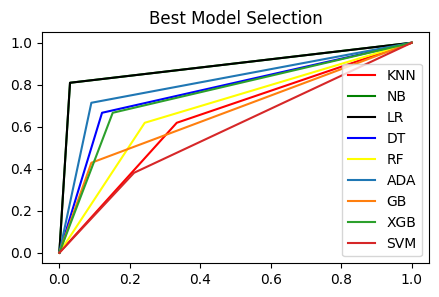

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(5,3))
plt.title("Best Model Selection")

plt.plot(model.knn_fpr, model.knn_tpr, label='KNN', color='r')
plt.plot(model.nb_fpr, model.nb_tpr, label='NB', color='g')
plt.plot(model.lr_fpr, model.lr_tpr, label='LR', color='black')
plt.plot(model.dt_fpr, model.dt_tpr, label='DT', color='blue')
plt.plot(model.rf_fpr, model.rf_tpr, label='RF', color='yellow')
plt.plot(model.ada_fpr, model.ada_tpr, label='ADA')
plt.plot(model.gb_fpr, model.gb_tpr, label='GB')
plt.plot(model.xgb_fpr, model.xgb_tpr, label='XGB')
plt.plot(model.svm_fpr, model.svm_tpr, label='SVM')

plt.legend()
plt.show()

In [ ]:
# from the above all models based on AUC and ROC we are going to select Logistic Regression

In [ ]:
#Logistic Regression
lr_reg = LogisticRegression()
lr_reg.fit(X_train,y_train)
lr_predictions = lr_reg.predict(X_test)
print(f"Logistic Regression Test Accuracy \n : {accuracy_score(y_test , lr_predictions)}")
print(f"Logistic Regression Confusion Matrix \n : {confusion_matrix(y_test,lr_predictions)}")
print(f"Logistic Regression Classification report \n : {classification_report(y_test,lr_predictions)}")

Logistic Regression Test Accuracy 
 : 0.9074074074074074
Logistic Regression Confusion Matrix 
 : [[32  1]
 [ 4 17]]
Logistic Regression Classification report 
 :               precision    recall  f1-score   support

           0       0.89      0.97      0.93        33
           1       0.94      0.81      0.87        21

    accuracy                           0.91        54
   macro avg       0.92      0.89      0.90        54
weighted avg       0.91      0.91      0.91        54



`Fine Tuning or Hyper Parameter Tuning`

**GridSearch CV**

In [ ]:
from sklearn.model_selection import GridSearchCV,RandomizedSearchCV
from sklearn.linear_model import LogisticRegression
reg = LogisticRegression()

In [32]:
param_grid = {
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear', 'saga'],
    'C': [0.01, 0.1, 1, 10, 100],
    'max_iter': [100, 500, 1000],
    'tol': [1e-4, 1e-3],
    'fit_intercept': [True, False],
    'class_weight': [None, 'balanced']
}

grid = GridSearchCV(
    LogisticRegression(),
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid.fit(X_train, y_train)

print("Best Parameters:", grid.best_params_)
print("Best Score:", grid.best_score_)

Best Parameters: {'C': 1, 'class_weight': None, 'fit_intercept': True, 'max_iter': 100, 'penalty': 'l1', 'solver': 'liblinear', 'tol': 0.0001}
Best Score: 0.8427061310782241


In [29]:
lr_reg = LogisticRegression(
    penalty='l1',
    C=1,
    l1_ratio=0.0,
    dual=False,
    tol=0.0001,
    fit_intercept=True,
    intercept_scaling=1,
    class_weight=None,
    random_state=None,
    solver='liblinear',
    max_iter=100,
    verbose=0,
    warm_start=False,
    n_jobs=None
)

lr_reg.fit(X_train, y_train)

lr_predictions = lr_reg.predict(X_test)

print(f"Logistic Regression Test Accuracy\n: {accuracy_score(y_test, lr_predictions)}")
print(f"Logistic Regression Confusion Matrix\n: {confusion_matrix(y_test, lr_predictions)}")
print(f"Logistic Regression Classification Report\n: {classification_report(y_test, lr_predictions)}")

Logistic Regression Test Accuracy
: 0.9074074074074074
Logistic Regression Confusion Matrix
: [[32  1]
 [ 4 17]]
Logistic Regression Classification Report
:               precision    recall  f1-score   support

           0       0.89      0.97      0.93        33
           1       0.94      0.81      0.87        21

    accuracy                           0.91        54
   macro avg       0.92      0.89      0.90        54
weighted avg       0.91      0.91      0.91        54



In [31]:
import pickle

with open("Heart_Disease_Prediction.pkl","wb") as f:
  pickle.dump(lr_reg,f)

with open("Heart_Disease_Prediction.pkl","rb") as f:
  m=pickle.load(f)